Cell 1: Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Configuration for prettier charts
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the Processed Master Dataset
# Note: In Jupyter, paths are relative to the notebook file
DATA_PATH = '../data/processed/master_aadhaar_thane.csv'

print(f"Loading data from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH)

# Convert 'month' back to period object (CSV saves it as string)
df['month'] = pd.to_datetime(df['month']).dt.to_period('M')

print("Data Loaded Successfully!")
print(f"Rows: {len(df)}, Columns: {len(df.columns)}")
display(df.head())

Loading data from: ../data/processed/master_aadhaar_thane.csv
Data Loaded Successfully!
Rows: 982, Columns: 12


,pincode,month,bio_child,bio_adult,bio_total,demo_child,demo_adult,demo_total,enrol_infant,enrol_child,enrol_adult,enrol_total
0,400601,2025-03,0.0,0.0,0.0,99.0,1058.0,1157.0,0.0,0.0,0.0,0.0
1,400601,2025-04,393.0,831.0,1224.0,104.0,783.0,887.0,0.0,0.0,0.0,0.0
2,400601,2025-05,575.0,1122.0,1697.0,0.0,0.0,0.0,80.0,30.0,14.0,124.0
3,400601,2025-06,165.0,670.0,835.0,0.0,0.0,0.0,45.0,31.0,1.0,77.0
4,400601,2025-07,407.0,912.0,1319.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.columns

Index(['pincode', 'month', 'bio_child', 'bio_adult', 'bio_total', 'demo_child',
       'demo_adult', 'demo_total', 'enrol_infant', 'enrol_child',
       'enrol_adult', 'enrol_total', 'total_txn', 'SGI_Score',
       'Identity_Churn', 'Bio_Distress_Adult', 'Child_Compliance',
       'Enrol_Saturation'],
      dtype='object')

In [10]:
df.head()

,pincode,month,bio_child,bio_adult,bio_total,demo_child,demo_adult,demo_total,enrol_infant,enrol_child,enrol_adult,enrol_total,total_txn,SGI_Score,Identity_Churn,Bio_Distress_Adult,Child_Compliance,Enrol_Saturation
0,400601,2025-03,0.0,0.0,0.0,99.0,1058.0,1157.0,0.0,0.0,0.0,0.0,1157.0,0.999136,0.913644,0.000000,0.000000,0.000000
1,400601,2025-04,393.0,831.0,1224.0,104.0,783.0,887.0,0.0,0.0,0.0,0.0,2111.0,0.159564,0.764205,1.059949,0.789157,0.000000
2,400601,2025-05,575.0,1122.0,1697.0,0.0,0.0,0.0,80.0,30.0,14.0,124.0,1821.0,0.999411,0.615807,1122.000000,0.998264,0.068057
3,400601,2025-06,165.0,670.0,835.0,0.0,0.0,0.0,45.0,31.0,1.0,77.0,912.0,0.998804,0.733844,670.000000,0.993976,0.084337
4,400601,2025-07,407.0,912.0,1319.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1319.0,0.999242,0.690909,912.000000,0.997549,0.000000


In [11]:
df.describe()

,pincode,bio_child,bio_adult,bio_total,demo_child,demo_adult,demo_total,enrol_infant,enrol_child,enrol_adult,enrol_total,total_txn,SGI_Score,Identity_Churn,Bio_Distress_Adult,Child_Compliance,Enrol_Saturation
count,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.00000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000,982.000000
mean,408510.113035,278.581466,573.529532,852.110998,32.689409,404.876782,437.566191,32.782077,16.580448,1.10998,50.472505,1340.149695,0.606541,0.777640,188.016390,0.801567,0.027222
std,9729.577141,519.380350,873.184620,1368.226921,89.252144,924.931447,1003.801177,92.823121,61.692532,4.27473,153.928610,2340.911616,0.373860,0.136199,402.672252,0.279860,0.040377
min,400601.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.430753,0.000000,0.000000,0.000000
25%,401105.000000,10.000000,80.000000,97.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,148.250000,0.238795,0.676037,1.073558,0.797514,0.000000
50%,401504.000000,66.500000,290.500000,375.000000,0.000000,20.500000,22.500000,2.000000,0.000000,0.00000,2.000000,527.000000,0.571126,0.763913,2.293400,0.909091,0.011184
75%,421203.000000,323.750000,731.750000,1046.000000,17.750000,392.000000,408.000000,21.000000,9.000000,0.00000,33.000000,1501.500000,0.996572,0.909091,200.000000,0.971429,0.041703
max,421605.000000,4759.000000,9314.000000,13462.000000,799.000000,10318.000000,10797.000000,1309.000000,905.000000,42.00000,2238.000000,25036.000000,0.999852,0.995708,4755.000000,0.999503,0.350137


Cell 2: The "Metric Factory" 

In [ ]:
#1. Define Total Activity (The Denominator) ---
# Total Transactions = Bio + Demo + Enrol
df['total_txn'] = (df['bio_total'] + df['demo_total'] + df['enrol_total'])

#Feature Engineering: The 5 Indicators ---
# Operational Synchronization Gap (Ghost Centers)
df['SGI_Score'] = abs(df['bio_total'] - df['demo_total']) / (df['bio_total'] + df['demo_total'] + 1)
# Identity Churn (Adult Instability)
df['Identity_Churn'] = (df['demo_adult'] + df['bio_adult']) / (df['total_txn'] + 1)
# Biometric Distress (Adults)
df['Bio_Distress_Adult'] = df['bio_adult'] / (df['demo_adult'] + 1)
# Child Compliance (Children)
df['Child_Compliance'] = df['bio_child'] / (df['bio_child'] + df['demo_child'] + 1)
# Enrollment Saturation
df['Enrol_Saturation'] = df['enrol_total'] / (df['total_txn'] + 1)

print("Metrics Calculated Successfully.")
display(df[['pincode', 'month', 'SGI_Score', 'Identity_Churn', 'Bio_Distress_Adult', 'Enrol_Saturation']].head())

Metrics Calculated Successfully.


,pincode,month,SGI_Score,Identity_Churn,Bio_Distress_Adult,Enrol_Saturation
0,400601,2025-03,0.999136,0.913644,0.000000,0.000000
1,400601,2025-04,0.159564,0.764205,1.059949,0.000000
2,400601,2025-05,0.999411,0.615807,1122.000000,0.068057
3,400601,2025-06,0.998804,0.733844,670.000000,0.084337
4,400601,2025-07,0.999242,0.690909,912.000000,0.000000


--- SYSTEM OPERATIONAL BASELINES ---
Median Volume (50th Percentile): 527 txns/month
Top 10% Volume Cutoff: 3218 txns/month

--- TIER COVERAGE STRATEGY ---
Tier 1 (Watchlist > 200): Covers 70.6% of all operational months.
Tier 2 (Critical > 500): Covers 51.2% of all operational months (The Core).


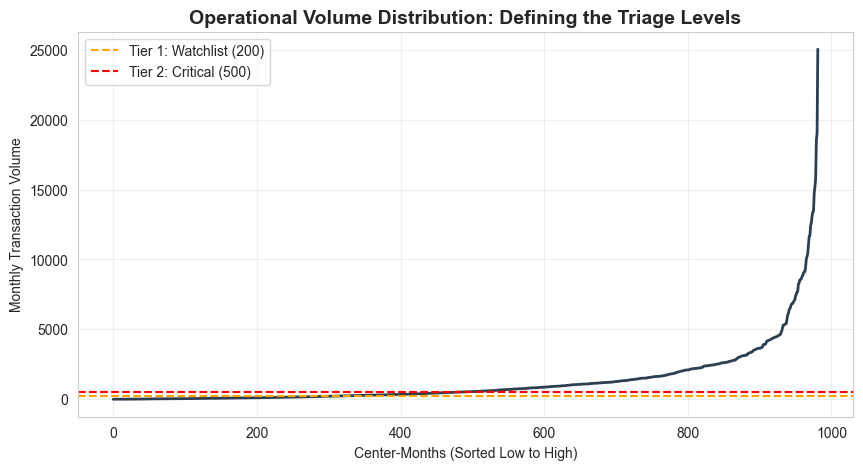

In [5]:
# --- CELL 3: Statistical Threshold Discovery ---
# Goal: Scientifically define "Small", "Medium", and "Large" centers based on data.

# 1. Analyze the Volume Distribution (Pareto Principle)
# We calculate what volume a center needs to be in the Top 50% (Median) and Top 90%
df_active = df[df['total_txn'] > 0].copy()
quantiles = df_active['total_txn'].quantile([0.25, 0.50, 0.75, 0.90, 0.95])

print("--- SYSTEM OPERATIONAL BASELINES ---")
print(f"Median Volume (50th Percentile): {int(quantiles[0.50])} txns/month")
print(f"Top 10% Volume Cutoff: {int(quantiles[0.90])} txns/month")

# 2. Define Our Strategic Tiers based on this data
# Tier 1 (Watchlist): > 200 (Ensures coverage of smaller centers)
# Tier 2 (Critical): > 500 (Matches the Median ~527, covering the core network)

tier_1_cutoff = 200
tier_2_cutoff = 500

# Calculate Data Coverage
coverage_tier1 = len(df[df['total_txn'] > tier_1_cutoff]) / len(df) * 100
coverage_tier2 = len(df[df['total_txn'] > tier_2_cutoff]) / len(df) * 100

print(f"\n--- TIER COVERAGE STRATEGY ---")
print(f"Tier 1 (Watchlist > {tier_1_cutoff}): Covers {coverage_tier1:.1f}% of all operational months.")
print(f"Tier 2 (Critical > {tier_2_cutoff}): Covers {coverage_tier2:.1f}% of all operational months (The Core).")

# 3. Visualize the "Elbow" to prove it
plt.figure(figsize=(10, 5))
sorted_vol = np.sort(df_active['total_txn'])
plt.plot(sorted_vol, color='#2c3e50', linewidth=2)
plt.axhline(tier_1_cutoff, color='orange', linestyle='--', label=f'Tier 1: Watchlist ({tier_1_cutoff})')
plt.axhline(tier_2_cutoff, color='red', linestyle='--', label=f'Tier 2: Critical ({tier_2_cutoff})')
plt.title("Operational Volume Distribution: Defining the Triage Levels", fontsize=14, fontweight='bold')
plt.xlabel("Center-Months (Sorted Low to High)")
plt.ylabel("Monthly Transaction Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [6]:
# Numeric extract for "Operational Volume Distribution" plot
import pandas as pd
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_rows', 200)

df_active = df[df['total_txn'] > 0].copy()
total_center_months = len(df)
active_months = len(df_active)

quantiles = df_active['total_txn'].quantile([0.25, 0.50, 0.75, 0.90, 0.95]).to_dict()
tier_1_cutoff = 200
tier_2_cutoff = 500

tier1_count = (df['total_txn'] > tier_1_cutoff).sum()
tier2_count = (df['total_txn'] > tier_2_cutoff).sum()
coverage_tier1_pct = tier1_count / total_center_months * 100
coverage_tier2_pct = tier2_count / total_center_months * 100

print("=== Volume distribution summary ===")
print(f"Total center-month records         : {total_center_months}")
print(f"Active (non-zero) center-months    : {active_months}")
print()
print("Quantiles (monthly transactions):")
for q, v in quantiles.items():
    print(f"  {int(q*100):>2d}th pct : {int(v)}")

print()
print("Tier cutoffs (policy):")
print(f"  Tier-1 (Watchlist) cutoff       : {tier_1_cutoff}")
print(f"  Tier-2 (Critical) cutoff        : {tier_2_cutoff}")
print()
print("Coverage (how many center-months exceed cutoff):")
print(f"  Tier-1 count (> {tier_1_cutoff}) : {tier1_count} ({coverage_tier1_pct:.1f}% of all months)")
print(f"  Tier-2 count (> {tier_2_cutoff}) : {tier2_count} ({coverage_tier2_pct:.1f}% of all months)")
print()
print("Top center-month volumes (highest 10):")
display(df_active.sort_values('total_txn', ascending=False)[['month','pincode','total_txn']].head(10).reset_index(drop=True))


=== Volume distribution summary ===
Total center-month records         : 982
Active (non-zero) center-months    : 982

Quantiles (monthly transactions):
  25th pct : 148
  50th pct : 527
  75th pct : 1501
  90th pct : 3218
  95th pct : 5139

Tier cutoffs (policy):
  Tier-1 (Watchlist) cutoff       : 200
  Tier-2 (Critical) cutoff        : 500

Coverage (how many center-months exceed cutoff):
  Tier-1 count (> 200) : 693 (70.6% of all months)
  Tier-2 count (> 500) : 503 (51.2% of all months)

Top center-month volumes (highest 10):


,month,pincode,total_txn
0,2025-11,421302,25036.0
1,2025-12,421302,19032.0
2,2025-10,421302,18507.0
3,2025-12,400612,15769.0
4,2025-11,421301,15198.0
5,2025-07,421302,14740.0
6,2025-11,400612,13451.0
7,2025-04,400612,13379.0
8,2025-12,421301,13089.0
9,2025-05,421302,12616.0


--- ANOMALY DETECTION REPORT ---
CRITICAL GHOST CENTERS (Tier 2): 179 Found
Action: IMMEDIATE PHYSICAL AUDIT. These are major hubs with broken data pipelines.
------------------------------------------------------------
       month  pincode  bio_total  demo_total  SGI_Score  total_txn
767  2025-08   421302     6767.0         0.0   0.999852     6767.0
803  2025-04   421306     4576.0         0.0   0.999782     4905.0
104  2025-08   400612     4800.0         0.0   0.999792     4800.0
762  2025-03   421302        0.0      4649.0   0.999785     4649.0
267  2025-03   401107        0.0      4154.0   0.999759     4154.0
709  2025-05   421201     3898.0         0.0   0.999744     3898.0
247  2025-05   401105     3689.0         0.0   0.999729     3689.0
804  2025-05   421306     3548.0         0.0   0.999718     3548.0
45   2025-04   400605     3154.0         0.0   0.999683     3154.0
901  2025-07   421503     2065.0         0.0   0.999516     2775.0


WATCHLIST GHOST CENTERS (Tier 1): 107 Fou

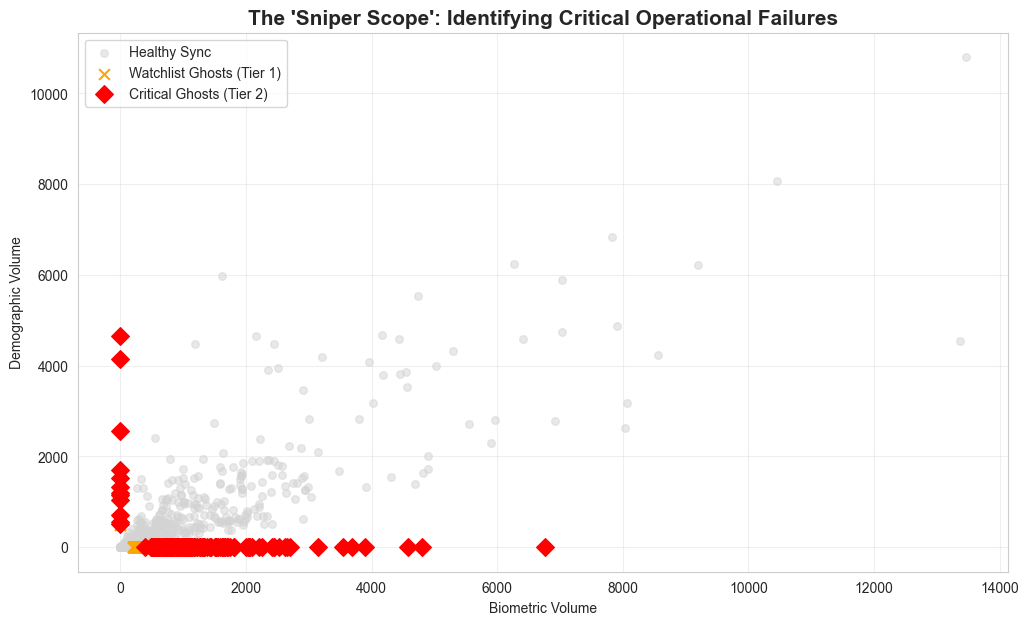

In [7]:
# --- CELL 4: The "Ghost Center" Detection Engine ---

# 1. Define the Ghost Criteria
# High Gap (> 0.8) means one stream is at least 9x larger than the other.
GHOST_THRESHOLD = 0.8 

# 2. Detect Tier 2 Ghosts (CRITICAL - Field Action Required)
# Logic: High Volume (> 500) AND High Gap
critical_ghosts = df[
    (df['total_txn'] > 500) & 
    (df['SGI_Score'] > GHOST_THRESHOLD)
].sort_values(by='total_txn', ascending=False)

# 3. Detect Tier 1 Ghosts (WATCHLIST - Digital Audit Required)
# Logic: Medium Volume (200 - 500) AND High Gap
watchlist_ghosts = df[
    (df['total_txn'] >= 200) & 
    (df['total_txn'] <= 500) & 
    (df['SGI_Score'] > GHOST_THRESHOLD)
].sort_values(by='total_txn', ascending=False)

# 4. The Output Report
print(f"--- ANOMALY DETECTION REPORT ---")
print(f"CRITICAL GHOST CENTERS (Tier 2): {len(critical_ghosts)} Found")
print(f"Action: IMMEDIATE PHYSICAL AUDIT. These are major hubs with broken data pipelines.")
print("-" * 60)
print(critical_ghosts[['month', 'pincode', 'bio_total', 'demo_total', 'SGI_Score', 'total_txn']].head(10))

print(f"\n" + "="*60 + "\n")

print(f"WATCHLIST GHOST CENTERS (Tier 1): {len(watchlist_ghosts)} Found")
print(f"Action: AUTOMATED ALERT. Send SMS/Email to Center Operator.")
print("-" * 60)
print(watchlist_ghosts[['month', 'pincode', 'bio_total', 'demo_total', 'SGI_Score', 'total_txn']].head(5))

# 5. Visual Proof: The "Sniper Scope" Plot
plt.figure(figsize=(12, 7))

# Plot Healthy Centers (Grey)
healthy = df[df['SGI_Score'] <= GHOST_THRESHOLD]
plt.scatter(healthy['bio_total'], healthy['demo_total'], c='lightgrey', alpha=0.5, label='Healthy Sync', s=30)

# Plot Tier 1 Ghosts (Orange)
plt.scatter(watchlist_ghosts['bio_total'], watchlist_ghosts['demo_total'], c='orange', marker='x', s=60, label='Watchlist Ghosts (Tier 1)')

# Plot Tier 2 Ghosts (Red)
plt.scatter(critical_ghosts['bio_total'], critical_ghosts['demo_total'], c='red', marker='D', s=80, label='Critical Ghosts (Tier 2)')

plt.title("The 'Sniper Scope': Identifying Critical Operational Failures", fontsize=15, fontweight='bold')
plt.xlabel("Biometric Volume")
plt.ylabel("Demographic Volume")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

--- REFINED CLUSTER IDENTIFICATION TABLE ---
Check SGI_Score now. You should see better separation (e.g., one cluster > 0.8, others lower).


,Cluster,SGI_Score,Identity_Churn,Bio_Distress_Adult,Enrol_Saturation,total_txn
0,0,0.624497,0.703455,107.172544,0.026684,596.811616
1,1,0.417162,0.699207,323.734596,0.060568,6217.295455
2,2,0.636249,0.918670,188.517885,0.019499,685.166162
3,3,0.620339,0.687098,346.995864,0.032809,1883.696970


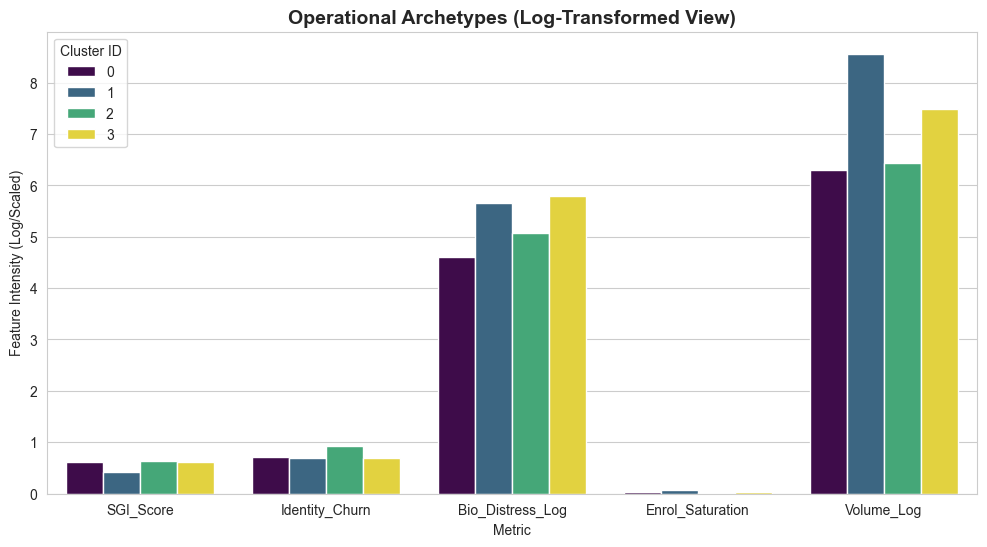

In [14]:
# --- CELL 5: Operational Segmentation (Refined with Log-Transforms) ---
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Prepare Data
# Aggregate to PIN level
pin_profile = df.groupby('pincode')[['SGI_Score', 'Identity_Churn', 'Bio_Distress_Adult', 'Enrol_Saturation', 'total_txn']].mean().reset_index()

# FILTER: Use Tier 1 cutoff (> 200) to exclude noise
pin_profile = pin_profile[pin_profile['total_txn'] > 200].copy()

# 2. FEATURE ENGINEERING (The Fix)
# We apply Log-Transform to the skewed features to prevent them from dominating the distance metric.
pin_profile['Bio_Distress_Log'] = np.log1p(pin_profile['Bio_Distress_Adult'])
pin_profile['Volume_Log'] = np.log1p(pin_profile['total_txn'])

# 3. Select Features for Clustering
# We use the LOG versions for clustering, but we will print the REAL versions for interpretation.
features_for_clustering = ['SGI_Score', 'Identity_Churn', 'Bio_Distress_Log', 'Enrol_Saturation', 'Volume_Log']
X = pin_profile[features_for_clustering]

# Scale the data (StandardScaler works much better on Log-Normal data)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Run K-Means (k=4)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
pin_profile['Cluster'] = kmeans.fit_predict(X_scaled)

# 5. Interpret the Clusters (The Centroid Table)
# Note: We group by the NEW Cluster IDs, but we look at the ORIGINAL metrics to understand them.
display_cols = ['SGI_Score', 'Identity_Churn', 'Bio_Distress_Adult', 'Enrol_Saturation', 'total_txn']
cluster_summary = pin_profile.groupby('Cluster')[display_cols].mean().reset_index()

print("--- REFINED CLUSTER IDENTIFICATION TABLE ---")
print("Check SGI_Score now. You should see better separation (e.g., one cluster > 0.8, others lower).")
display(cluster_summary)

# 6. Visualize to Confirm
# We visualize the scaled features to see what the Algorithm 'saw'
cluster_summary_scaled = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_for_clustering)
cluster_summary_scaled['Cluster'] = range(4)
cluster_summary_melt = cluster_summary_scaled.melt(id_vars='Cluster', value_vars=features_for_clustering)

plt.figure(figsize=(12, 6))
sns.barplot(data=cluster_summary_melt, x='variable', y='value', hue='Cluster', palette='viridis')
plt.title("Operational Archetypes (Log-Transformed View)", fontsize=14, fontweight='bold')
plt.ylabel("Feature Intensity (Log/Scaled)")
plt.xlabel("Metric")
plt.legend(title="Cluster ID")
plt.show()

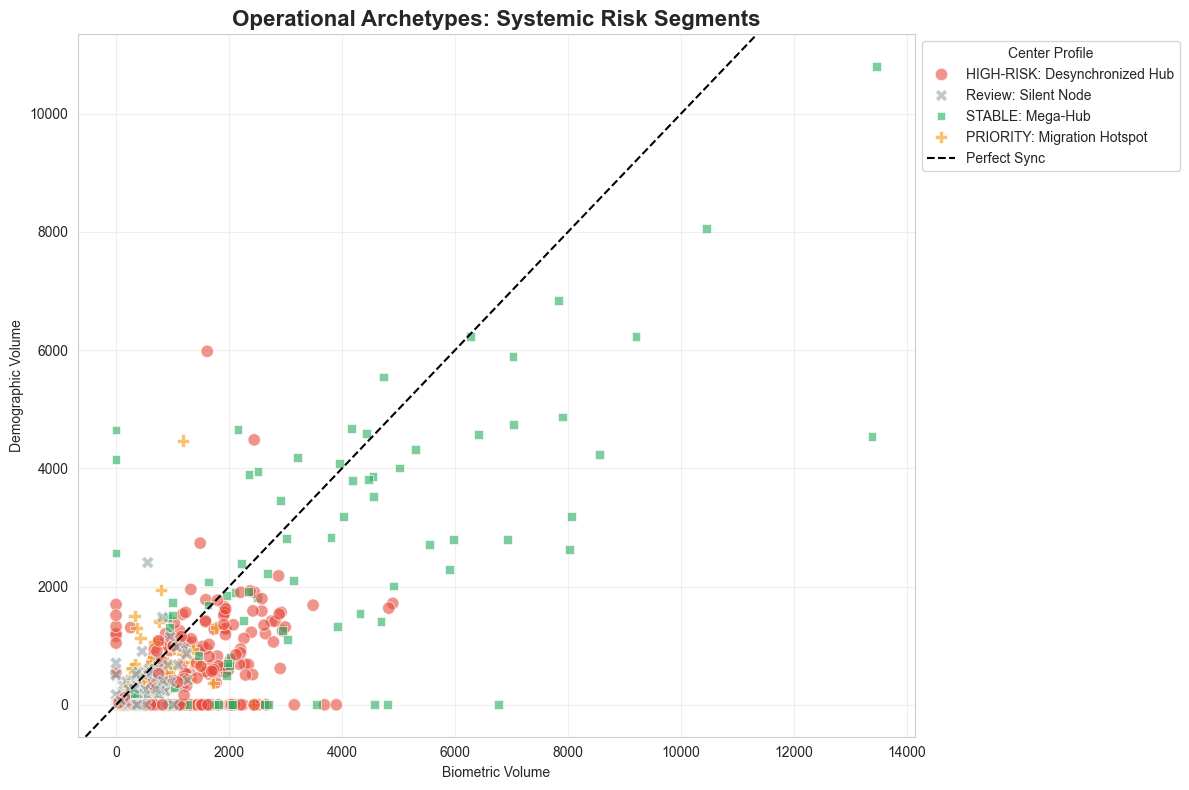


--- FINAL AUDIT TARGETS (REPEAT OFFENDERS) ---
Logic: Centers that triggered 'Critical Ghost' alert in ≥ 2 separate months.
Identified 42 High-Confidence Targets.
------------------------------------------------------------


,pincode,ghost_months,Category
0,421201,6,HIGH-RISK: Desynchronized Hub
1,401105,6,HIGH-RISK: Desynchronized Hub
2,400709,6,HIGH-RISK: Desynchronized Hub
3,421401,6,HIGH-RISK: Desynchronized Hub
4,421004,5,HIGH-RISK: Desynchronized Hub
5,421305,5,HIGH-RISK: Desynchronized Hub
6,400601,5,HIGH-RISK: Desynchronized Hub
7,400604,5,HIGH-RISK: Desynchronized Hub
8,421202,5,HIGH-RISK: Desynchronized Hub
9,401101,5,HIGH-RISK: Desynchronized Hub


In [16]:
# --- CELL 6: Final Labeling & Hybrid Export Strategy ---

# 1. Apply Scientifically Accurate Labels (The "Type")
def get_cluster_label(cluster_id):
    if cluster_id == 3:
        return 'HIGH-RISK: Desynchronized Hub' # High Distress + High Volume + Desync Tendency
    elif cluster_id == 2:
        return 'PRIORITY: Migration Hotspot'   # Highest Churn
    elif cluster_id == 1:
        return 'STABLE: Mega-Hub'              # Highest Volume, Good Sync
    elif cluster_id == 0:
        return 'Review: Silent Node'           # Low Volume
    else:
        return 'Unknown'

# Apply labels to the dataset
pin_labels = pin_profile[['pincode', 'Cluster']].copy()
pin_labels['Category'] = pin_labels['Cluster'].apply(get_cluster_label)

# Merge back to the main DataFrame
final_df = df.merge(pin_labels, on='pincode', how='left')
final_df['Category'] = final_df['Category'].fillna('Tier 3: Noise (<200)')

# 2. The Visualization (Showing the Ecosystem)
# We plot the operational archetypes to show we understand the "System Behavior"
plot_data = final_df[final_df['Category'] != 'Tier 3: Noise (<200)']

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=plot_data, 
    x='bio_total', 
    y='demo_total', 
    hue='Category',
    style='Category',
    palette={
        'HIGH-RISK: Desynchronized Hub': '#e74c3c', # Red
        'PRIORITY: Migration Hotspot': '#f39c12',   # Orange
        'STABLE: Mega-Hub': '#27ae60',              # Green
        'Review: Silent Node': '#95a5a6'            # Grey
    },
    s=80,
    alpha=0.6
)
plt.title("Operational Archetypes: Systemic Risk Segments", fontsize=16, fontweight='bold')
plt.xlabel("Biometric Volume")
plt.ylabel("Demographic Volume")
plt.axline((0, 0), slope=1, color='black', linestyle='--', label="Perfect Sync")
plt.legend(title="Center Profile", loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 3. The "Hit List" (The Specific Offenders)
# Logic: We go back to the 'critical_ghosts' dataframe (from Cell 4).
# A true Ghost Center is a Repeat Offender.
# We count how many months a PIN appeared in the Critical Ghost list.

# Get the counts
ghost_counts = critical_ghosts['pincode'].value_counts().reset_index()
ghost_counts.columns = ['pincode', 'ghost_months']

# FILTER: We only indict centers that failed in 2 or more months.
# One month could be a glitch. Two months is a pattern.
confirmed_targets = ghost_counts[ghost_counts['ghost_months'] >= 2].copy()

# Add the operational context (Cluster Label) to the report
confirmed_targets = confirmed_targets.merge(pin_labels[['pincode', 'Category']], on='pincode', how='left')

print(f"\n--- FINAL AUDIT TARGETS (REPEAT OFFENDERS) ---")
print(f"Logic: Centers that triggered 'Critical Ghost' alert in ≥ 2 separate months.")
print(f"Identified {len(confirmed_targets)} High-Confidence Targets.")
print("-" * 60)
display(confirmed_targets)

# Export
confirmed_targets.to_csv('final_audit_targets_confirmed.csv', index=False)